# Часть 1. Анализ FastQC

На сервере была создана следующая структура папок:

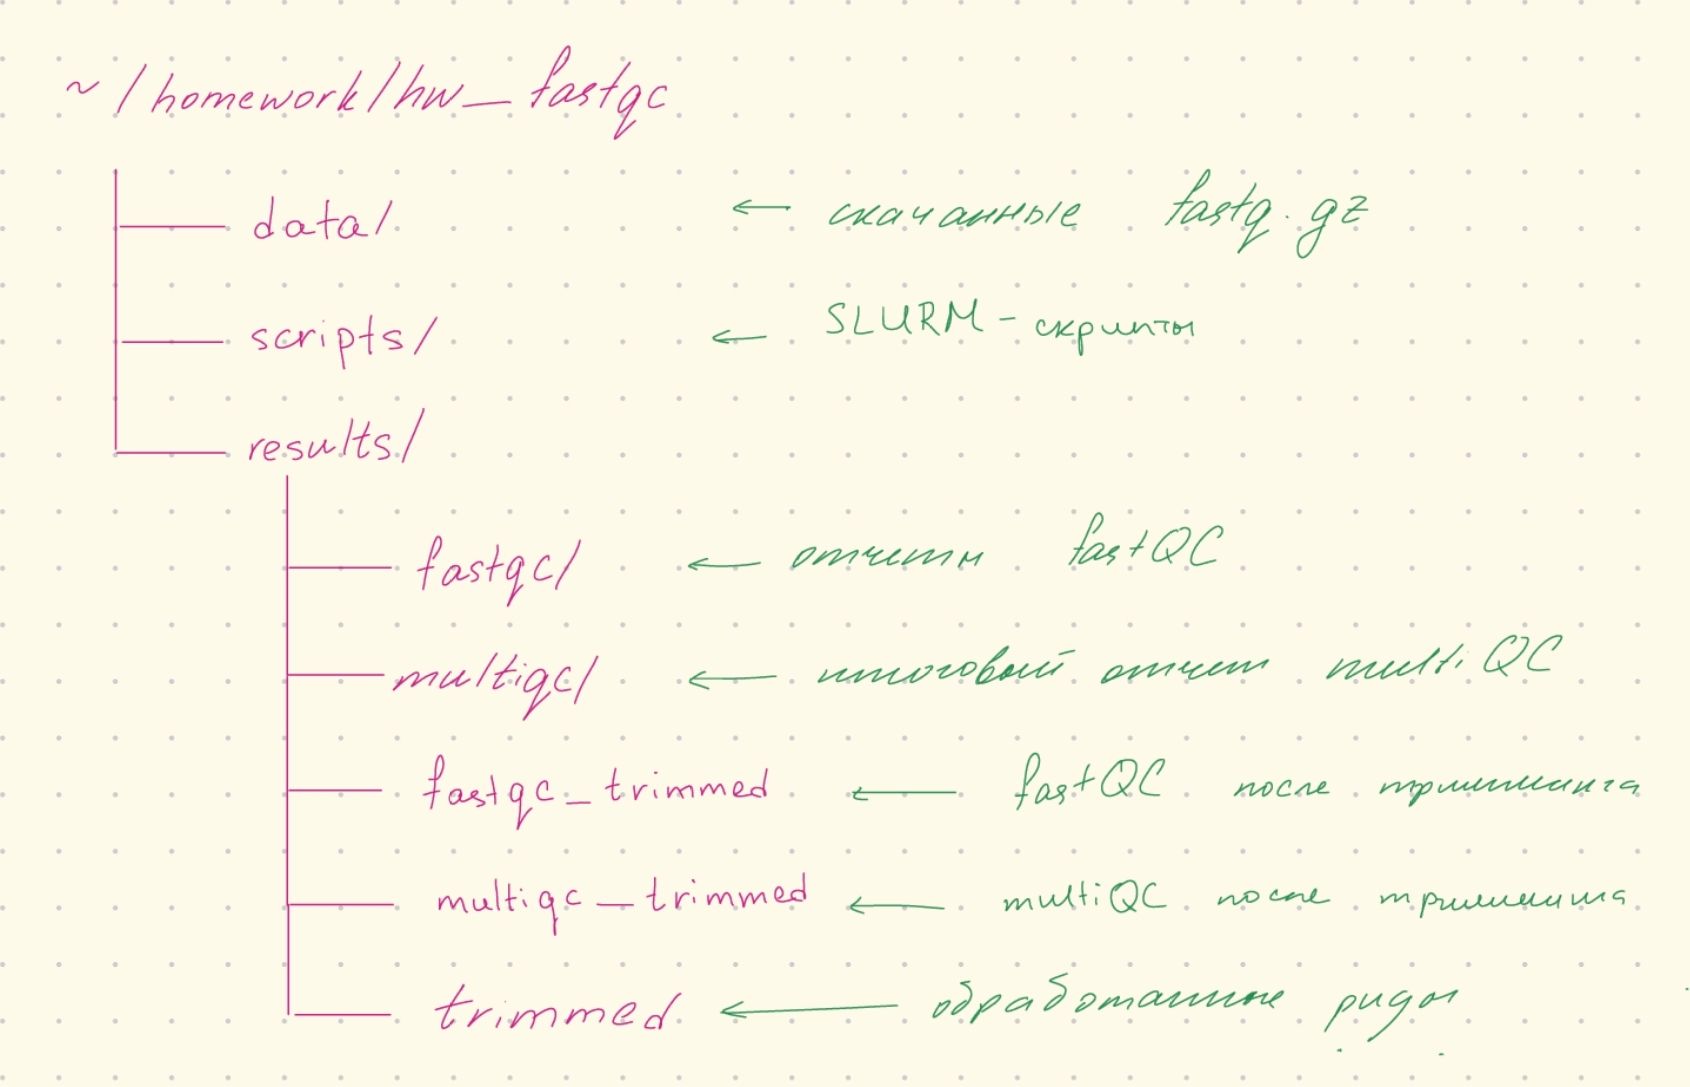
При помощи команд:
```
mkdir -p ~/homework/hw_fastqc
cd ~/homework/hw_fastqc
mkdir -p ~/homework/hw_fastqc/{data,scripts,results/fastqc,results/multiqc}
```



На сайте SRA Explorer (https://sra-explorer.info/#) были найдены ERR-раны из проекта PRJEB84057.

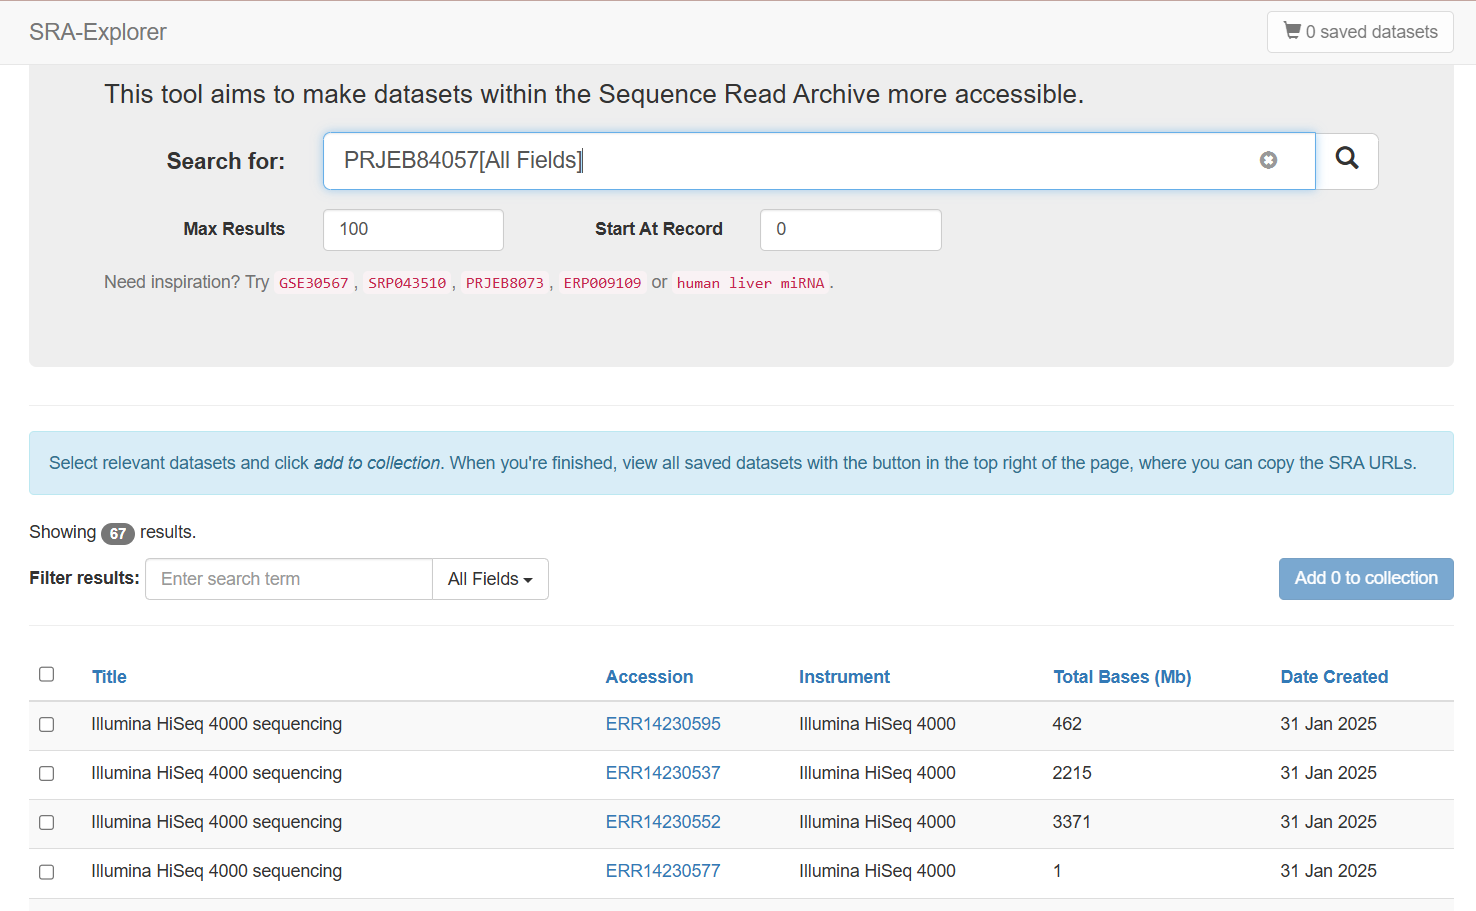

Среди них 4 размером до 1000 мб были добавлены в коллекцию.

Сайт сам предложил нам sh-скрипт для скачивания, который был использован нами с этой целью в дальнейшем
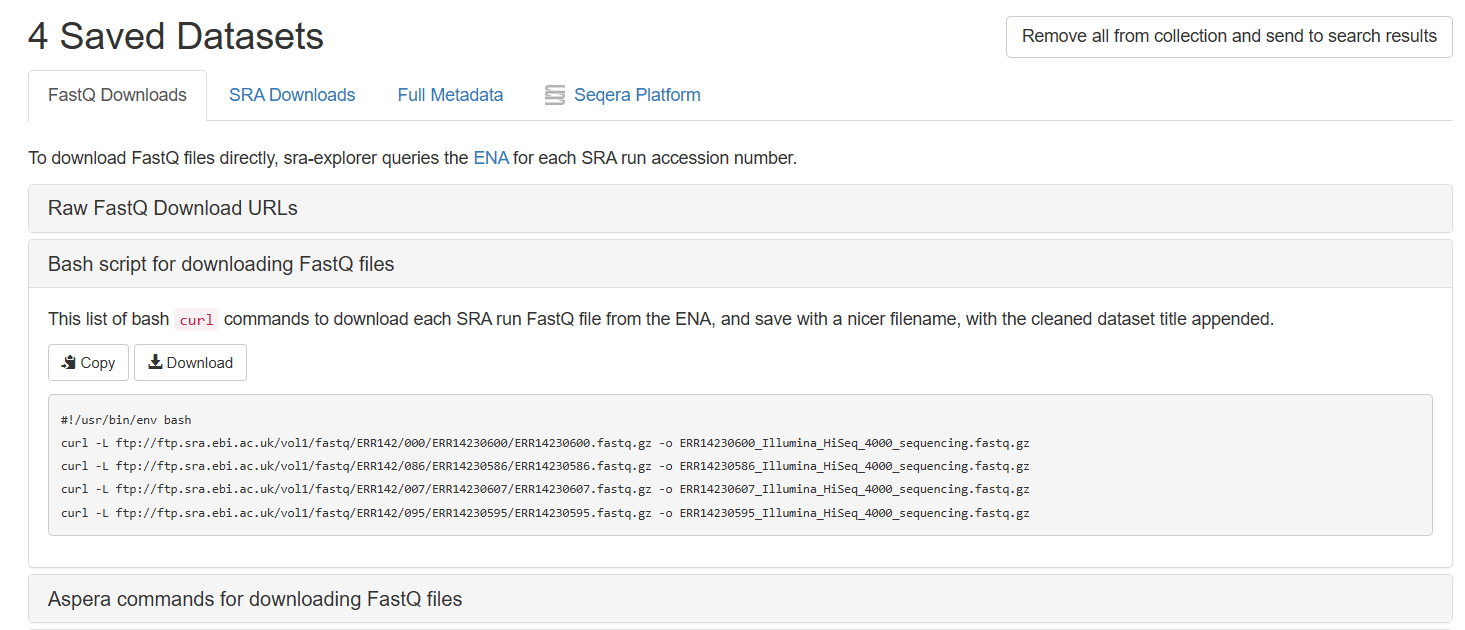

Собственно, на сервере в папке data создаем sh-скрипт download_fastq.sh для скачивания этих 4ех ERR-ранов:
```
cd ~/homework/hw_fastqc/data
vim download_fastq.sh
```



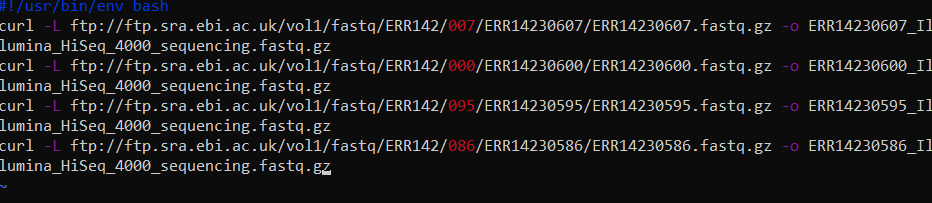

После скипт был запущен:
```
chmod +x download_fastq.sh
./download_fastq.sh
```



Предварительно нами из учетной записи была активирована конда:
```
/home/STUDY/FBMF/bioinformatics/anaconda3/bin/conda init bash
source ~/.bashrc
```
Подключена биоконда:
```
conda config --add channels defaults
conda config --add channels bioconda
conda config --add channels conda-forge
```
А также создано окружение qc_env с FastQC и MultiQC:
```
conda create -y -n qc_env fastqc multiqc
conda activate qc_env
```






В папке scripts:
```
cd ~/homework/hw_fastqc/scripts
```
Создаем скрипт run_fastqc_multiqc.slurm
```
vim run_fastqc_multiqc.slurm
```
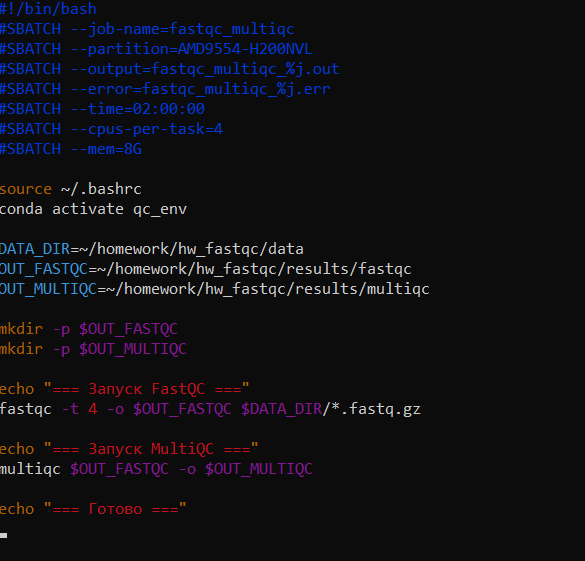





Этот скрипт запускает fastQC для загруженных нами раннее файлов в папку ~/homework/hw_fastqc/data и сохраняет результаты в ~/homework/hw_fastqc/results/fastqc, после чего собирает их в общий отчет multiQC в ~/homework/hw_fastqc/results/multiqc

Полученный отчет multiqc_report.html был скачан из папки results/multiqc на локальный компьютер:
```
scp studfbmf02_12@calc.cod.phystech.edu:~/homework/hw_fastqc/results/multiqc/multiqc_report.html .
```

# Часть 2. Тримминг

По отчету MultiQC адаптерная контаминация отсутствует (все образцы имеют <0.1% адаптеров).
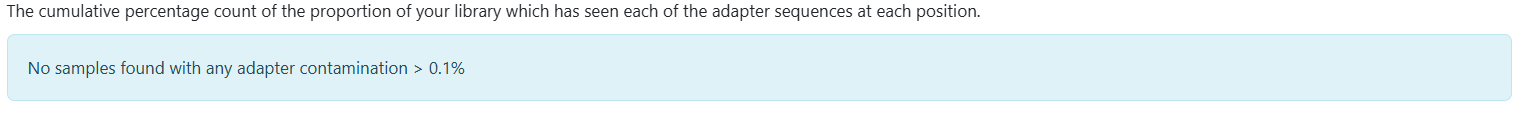

Также, на графике Sequence Quality Histograms (mean quality across each base position) линии качества остаются в зеленой зоне по всей длине рида. Участков с качеством ниже Q20, включая конец ридов, не наблюдается.
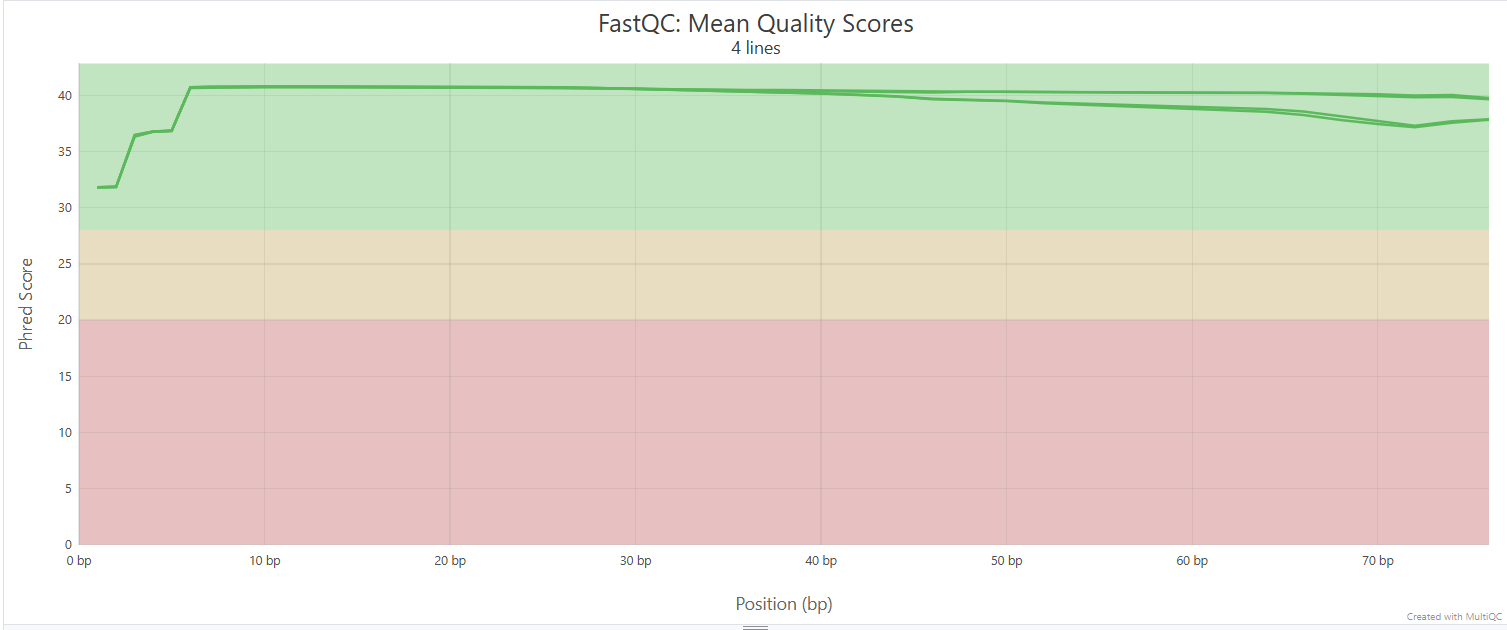

Таким образом, данные изначально имеют высокое качество, и тримминг не должен привести к существенным изменениям.



В наше окружение установили fastp:
```
conda install -n qc_env -c bioconda fastp
```
После чего в папке scripts был создан скрипт run_fastp.slurm:
```
cd ~/homework/hw_fastqc/scripts/
vim run_fastp.slurm
```

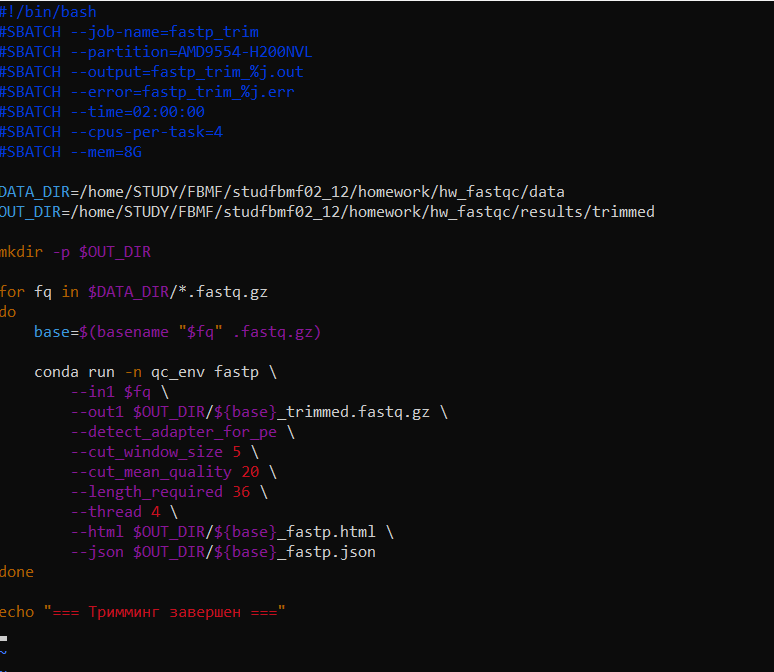

Этот скрипт запускает fastp для загуженных в /home/STUDY/FBMF/studfbmf02_12/homework/hw_fastqc/data файлов, автоматически обрезает адаптеры, применяет скользящее окно 5:20 для удаления низкокачественных участков, отбрасывает риды короче 36 п.н. и сохраняет очищенные файлы и отчеты в /home/STUDY/FBMF/studfbmf02_12/homework/hw_fastqc/results/trimmed

Приложим также скриншот папки на сервере c созданными файлами тримминга:
```
ls -la --time=ctime /home/STUDY/FBMF/studfbmf02_12/homework/hw_fastqc/results/trimmed
```
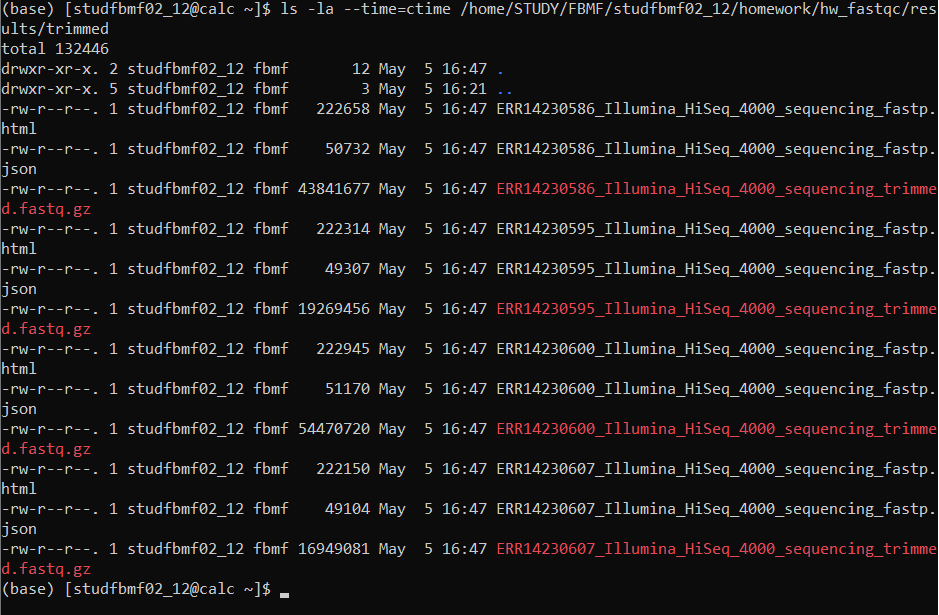


Можем заметить, что для каждого из четырех образцов (ERR14230586, ERR14230595, ERR14230600, ERR14230607) присутствуют:

*   *_trimmed.fastq.gz - очищенные риды
*   *_fastp.html - отчет fastp
*   *_fastp.json - метрики fastp

# Часть 3. Контроль качества после тримминга

В папке scripts написали скрипт run_fastqc_trimmed.slurm
```
vim run_fastqc_trimmed.slurm
```



  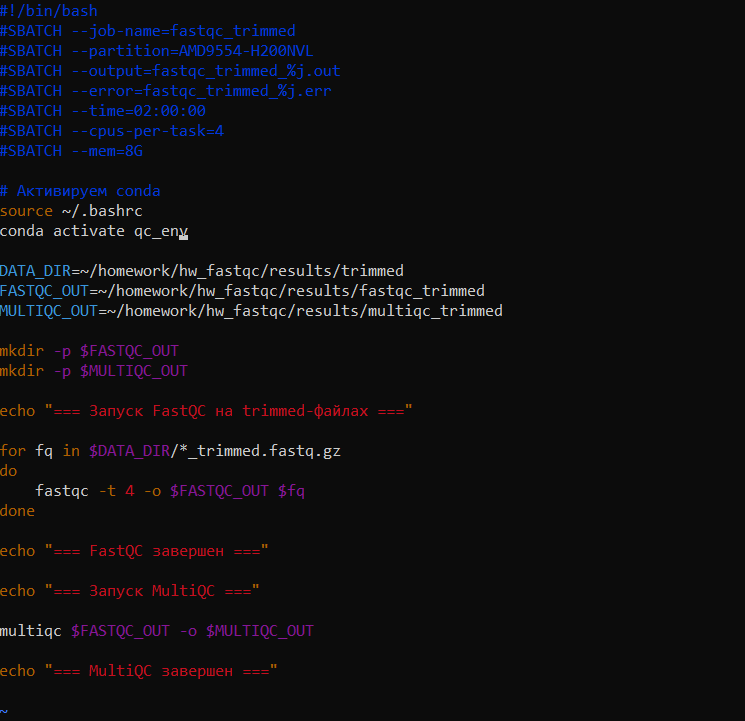

Этот скрипт запускает fastQC для всех trimmed-файлов из директории ~/homework/hw_fastqc/results/trimmed, полученных в предыдущей части, и сохраняет результаты в ~/homework/hw_fastqc/results/fastqc_trimmed, после чего собирает их в единый отчет multiQC в ~/homework/hw_fastqc/results/multiqc_trimmed.

Аналогично части 1 файл multiqc_trimmed.html был скачан на локальный компьютер.

Сравним отчеты multiqc до применения fastp и после

## General statistic

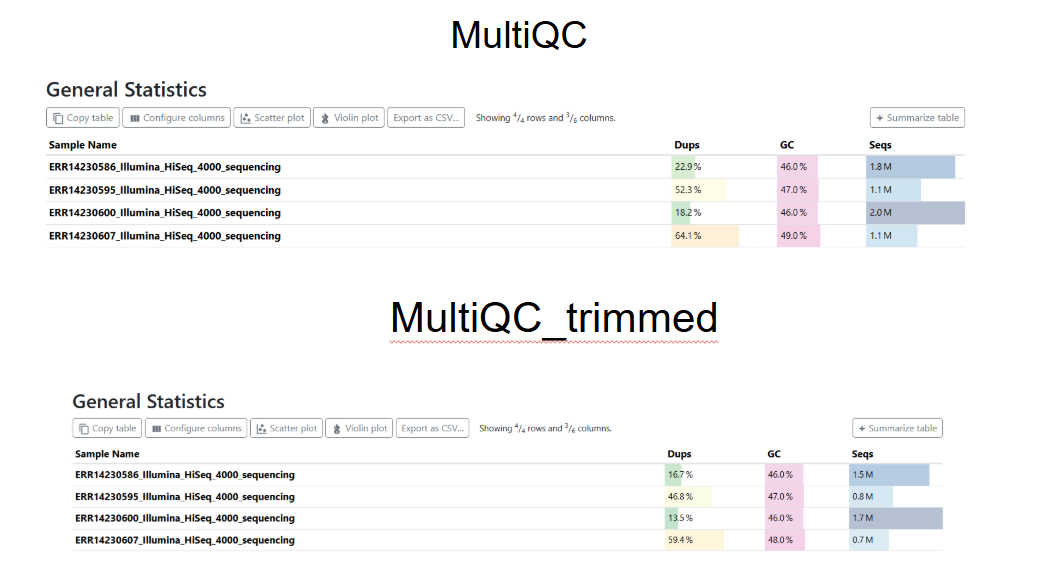

После тримминга наблюдается снижение уровня дупликаций во всех образцах. Это можно связать с тем, что fastp удаляет низкокачественные и адаптерные фрагменты, которые часто приводят к искусственному росту дупликаций. Уменьшение дупликаций свидетельствует о повышении уникальности данных.

## Sequence Counts

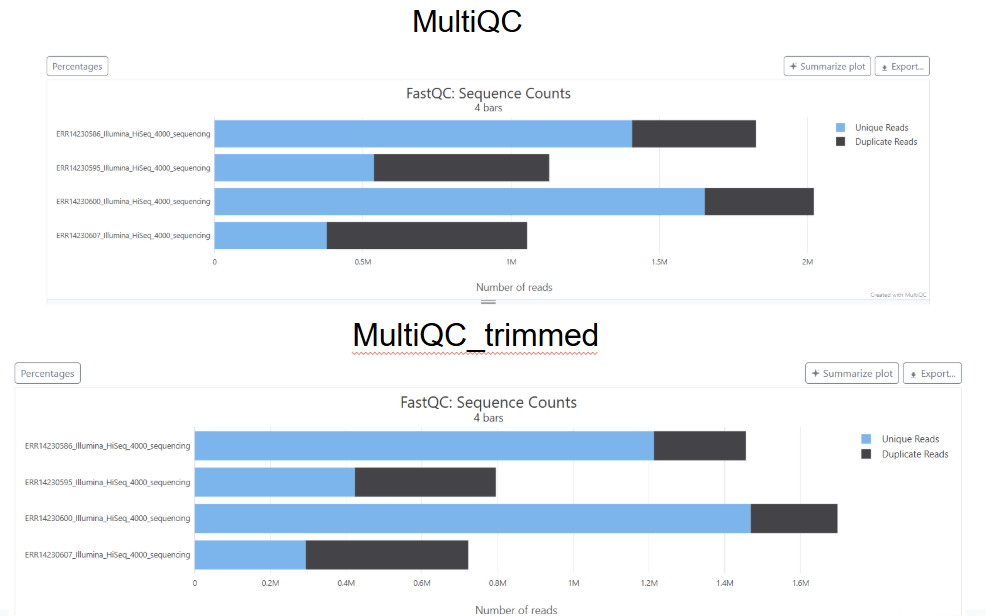

После тримминга общее число ридов уменьшилось, что связано с удалением низкокачественных и ,возможно, адаптерных последовательностей (как мы помним их было меньше 0.1%). При этом доля уникальных ридов увеличилась, а доля дупликатов уменьшилась, что указывает на улучшение качества данных и повышение информативности оставшихся ридов.

## Sequence Quality Histograms

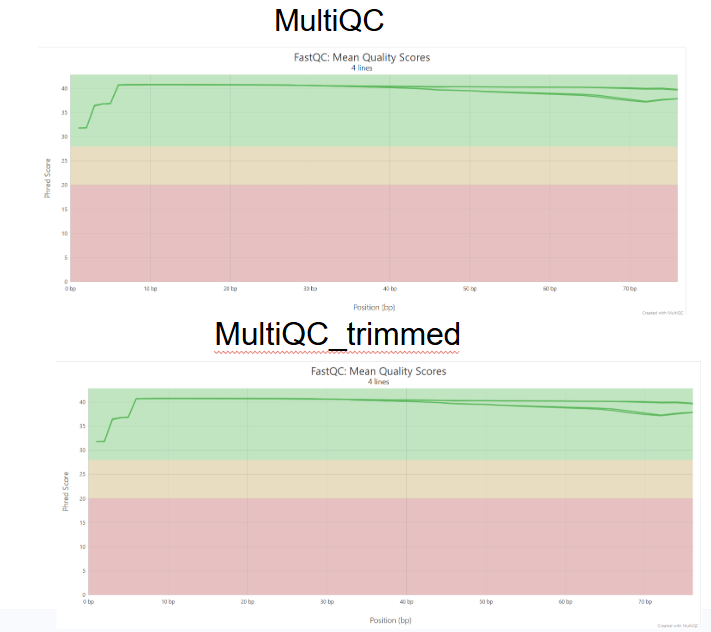

Мы можем заметить, что среднее качество по позициям практически не изменилось после тримминга. Это скорее всего связано с тем, что выбранные нами риды (как показывают результаты частей 1 и 2) уже имеют высокое качество по всей длине и fastp удалил только небольшие низкокачественные участки. Так как доля таких участков была минимальной, общий вид графика остался практически неизменным.

## Per Sequence Quality Scores

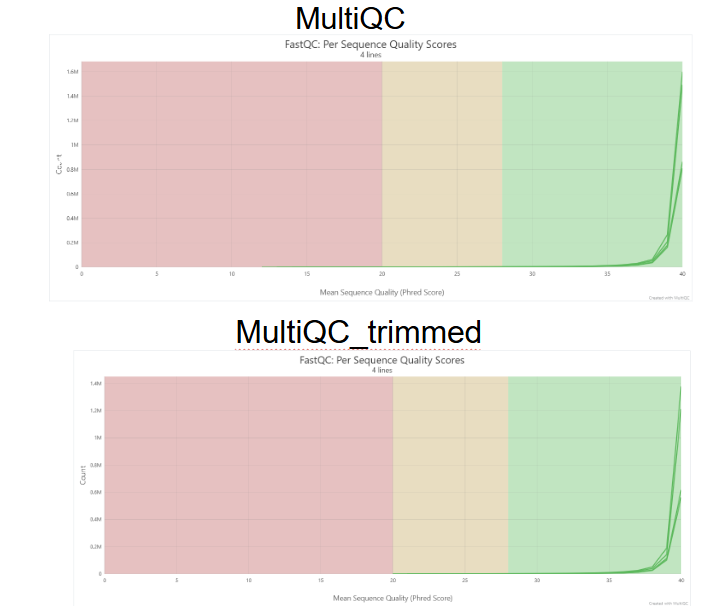

После тримминга наклон распределения средних качеств ридов стал менее крутым. Это связано с тем, что fastp удалил низкокачественные участки, но при этом слегка увеличил вариативность средних качеств среди оставшихся ридов. В результате распределение стало более плавным, хотя пик по‑прежнему находится в области высоких значений Phred (около 40).

## Per Sequence GC Content

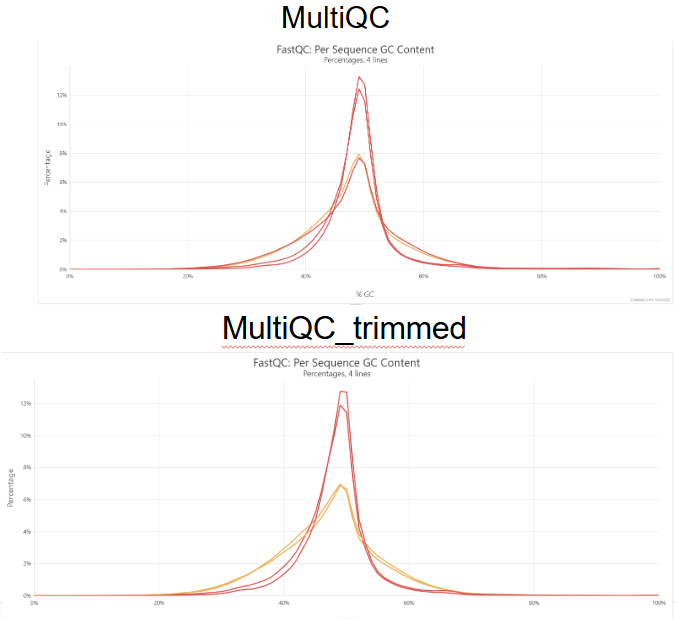

После тримминга одна из кривых GC-состава перешла из красной в желтую. Это означает, что распределение GC-состава стало ближе к нормальному: fastp удалил технические и низкокачественные последовательности, которые искажали GC-профиль. Однако небольшие отклонения все еще присутствуют, поэтому метрика улучшилась, но не достигла полностью нормального уровня.

## Per Base N Content

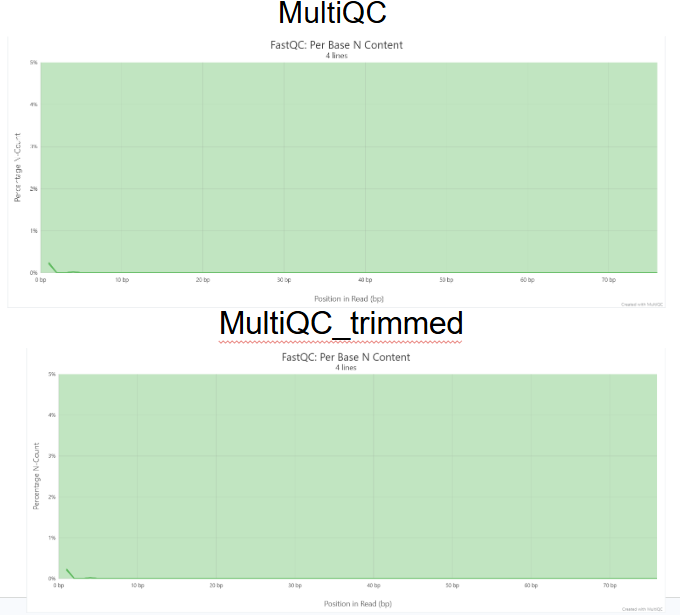

Base N content практически не изменился после тримминга и остается близким к нулю на всех позициях, что, как уже не раз замечалось ранее, указывает на высокое качество исходных данных.

## Sequence Length Distribution

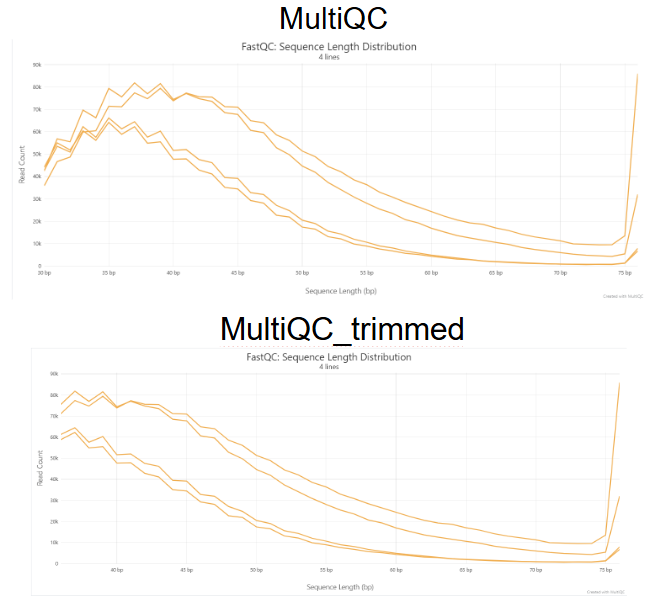

После тримминга ярко выраженный пик коротких ридов, наблюдавшийся до тримминга, исчез. Этот пик скорее всего был связан с техническими ридами, а также с сильно обрезанными низкокачественными последовательностями. После их удаления распределение стало более плавным и равномерным, без резких максимумов. Максимум по‑прежнему находится в области коротких длин, но теперь он выражен не как узкий пик, а как мягкое начало распределения. Это указывает на то, что fastp удалил аномально короткие риды, не искажая естественную структуру длин оставшихся ридов.

## Sequence Duplication Levels

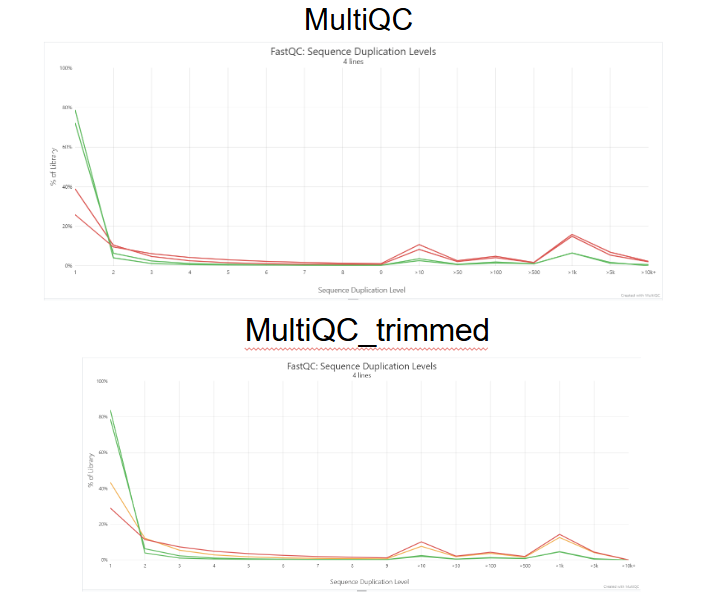

После тримминга одна из кривых из красной перешла в желтую, что указывает на уменьшение уровня дупликации (что уже отмечалось ранее), опять же, fastp удалил технические и повторяющиеся риды, что снизило долю дубликатов. Однако небольшое превышение нормы все еще сохраняется.

## Adapter Content

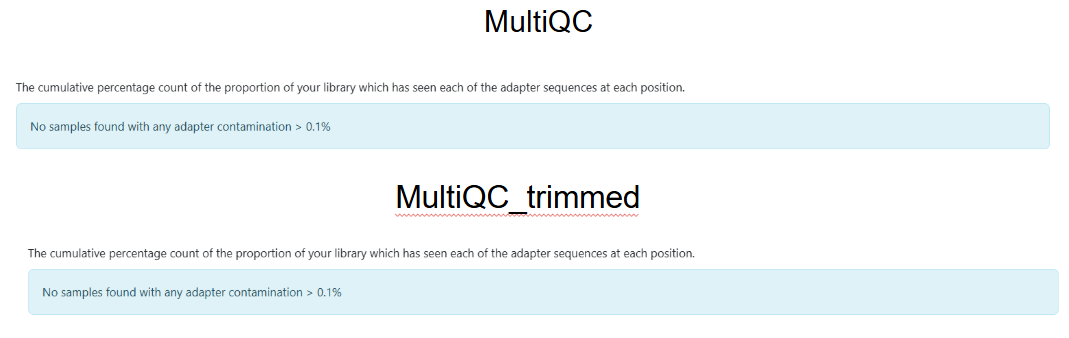

До и после тримминга уровень адаптерной контаминации остается ниже 0.1%. MultiQC не обнаруживает адаптеров ни в одном из образцов, поэтому тримминг не приводит к изменениям в этой метрике.

# Вывод

Тримминг улучшил качество данных за счет удаления коротких, технических и дублированных ридов, что привело к сглаживанию распределения длин и снижению уровня дупликации. Адаптерная контаминация отсутствовала изначально и не изменилась. Среднее качество по позициям остается высоким (Q > 30) по всей длине ридов, без участков с Q < 20.